  show_id     type                             title  \
0      s1    Movie              Dick Johnson Is Dead   
1      s2  TV Show                     Blood & Water   
2      s3  TV Show                         Ganglands   
3      s4  TV Show             Jailbirds New Orleans   
4      s5  TV Show                      Kota Factory   
5      s6  TV Show                     Midnight Mass   
6      s7    Movie  My Little Pony: A New Generation   
7      s8    Movie                           Sankofa   
8      s9  TV Show     The Great British Baking Show   
9     s10    Movie                      The Starling   

                        director  \
0                Kirsten Johnson   
1                            NaN   
2                Julien Leclercq   
3                            NaN   
4                            NaN   
5                  Mike Flanagan   
6  Robert Cullen, José Luis Ucha   
7                   Haile Gerima   
8                Andy Devonshire   
9                 Theod

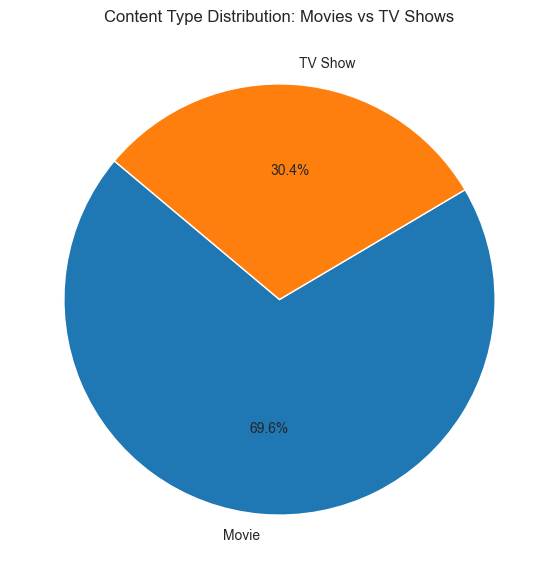

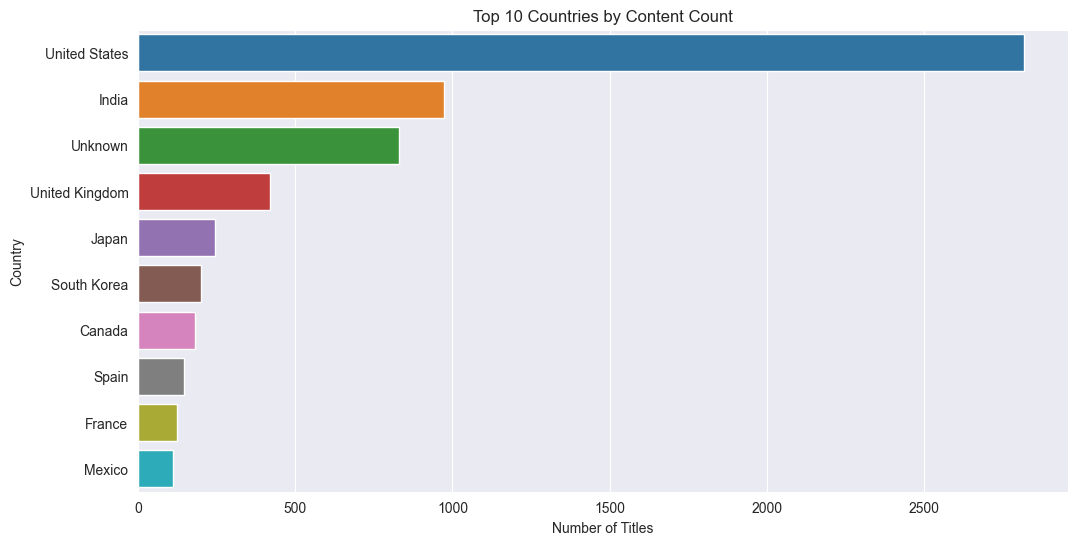

Business Insight:
The top countries contributing to Netflix's content library include: United States, India, Unknown, United Kingdom, Japan, South Korea, Canada, Spain, France, Mexico.
This information is useful for content acquisition strategies by guiding Netflix to invest in local production in key international markets, leverage popular local titles to engage a global audience, and tailor content to specific cultural preferences to attract new subscribers and improve retention.



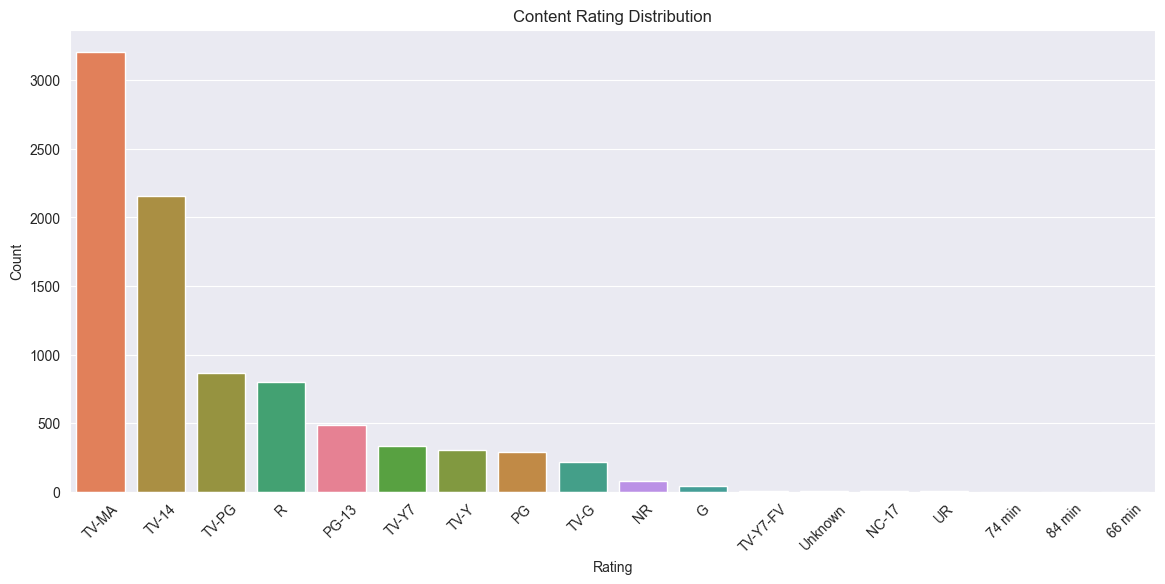

Business Insight:
Most common ratings on Netflix are ['TV-MA', 'TV-14', 'TV-PG'].
Netflix’s recommendation algorithm is driven by user behavior, but content rating plays a significant role in filtering and personalization the movies to the users taste and show similar content.
For example, if you are watching kid movies it will show you similar kind of kid movies.



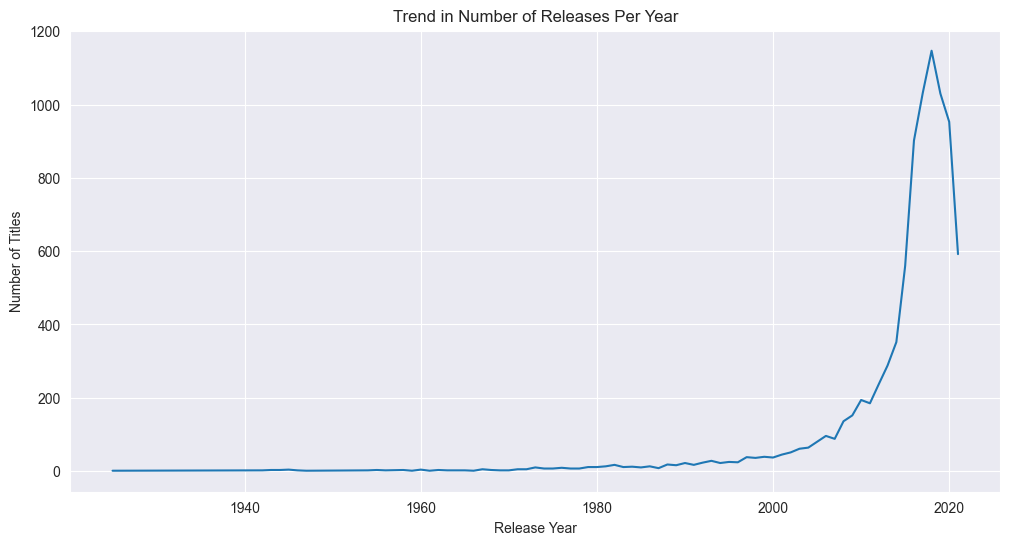

Business Insight:
Netflix has followed the classic business life cycle phases over time: launch, growth, shake-out, maturity, and decline. Currently, Netflix is in the maturity phase with some continued growth.
Trends show that Netflix ramped up significantly around 2012 and has stabilized after 2020.
Trend Using past trends to forecast for future planning of content.
Personalized marketing: based on the trends they watch.
Netflix can design marketing for  underrepresented content areas.
Allocate budget for movies based on the trends of the movies.



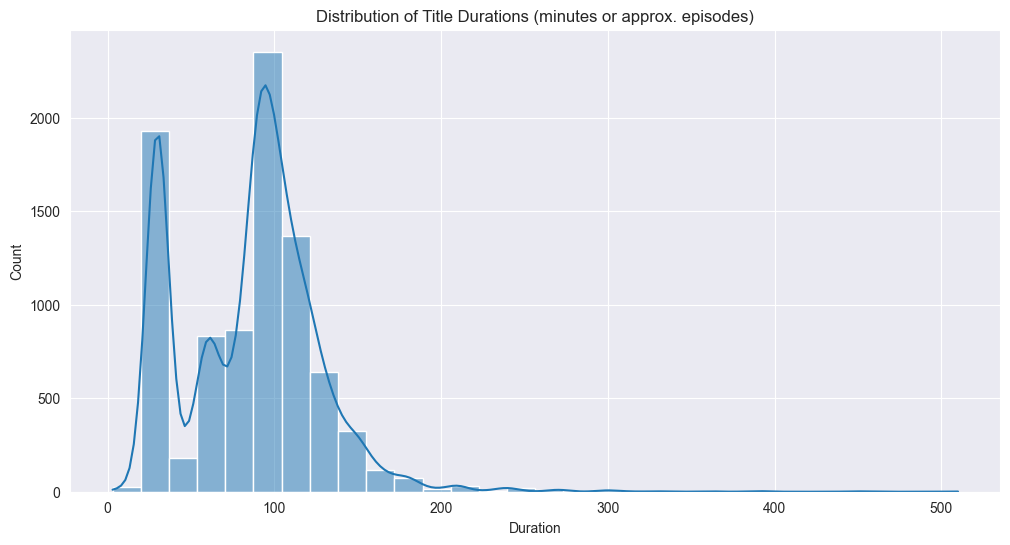

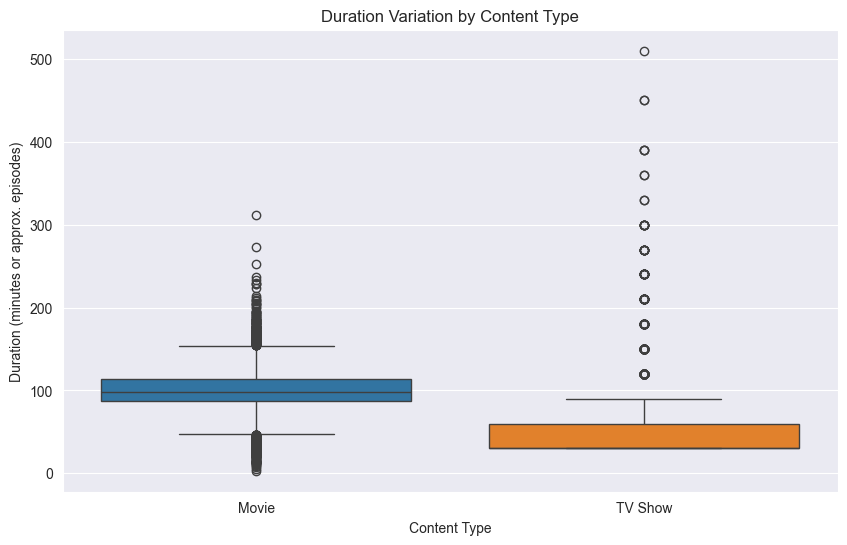

Movie duration (mean ± std): 99.6 ± 28.3 minutes
TV Show duration (mean ± std, approx. episodes): 52.9 ± 47.5
Business Insight:
Movies have shorter, consistent durations (mean ~99.6 min), suitable for quick viewing.
TV Shows have longer, variable durations (mean ~52.9 min), promoting binge-watching.
Netflix can tailor user engagement strategies by recommending movies for casual viewing and shows for long-term retention.



In [4]:
#Siddharth Shenoy - shenoy22@purdue.edu
#Ramana Prabhu Sana - rsana@purdue.edu

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

# Load the Netflix dataset
netflix_df = pd.read_csv('/Users/prabhusana/Downloads/netflix_titles.csv')

# Basic data inspection
print(netflix_df.head(10))
print("Missing values per column:\n", netflix_df.isnull().sum())

netflix_df.fillna('Unknown', inplace=True)
print("Missing values per column after fillna:\n", netflix_df.isnull().sum())

print("Number of duplicate rows:", netflix_df.duplicated().sum())
print(netflix_df.info())

# --- Data Exploration: Content Type Distribution ---

type_counts = netflix_df['type'].value_counts()

print("Distribution of Content Types:\n", type_counts)

plt.figure(figsize=(7,7))
sns.set_style("darkgrid")  # optional styling for consistency
plt.pie(type_counts, labels=type_counts.index, autopct='%1.1f%%', startangle=140)
plt.title('Content Type Distribution: Movies vs TV Shows')
plt.show()


# --- Country Analysis ---
country_counts = netflix_df['country'].dropna().value_counts().head(10)
plt.figure(figsize=(12,6))
sns.set_style("darkgrid")
sns.barplot(x=country_counts.values, y=country_counts.index, hue=country_counts.index)
plt.title('Top 10 Countries by Content Count')
plt.xlabel('Number of Titles')
plt.ylabel('Country')
plt.show()

print(f"Business Insight:\n"
      f"The top countries contributing to Netflix's content library include: {', '.join(country_counts.index)}.\n"
      "This information is useful for content acquisition strategies by guiding Netflix to invest in local production in key international markets, leverage popular local titles to engage a global audience, and tailor content to specific cultural preferences to attract new subscribers and improve retention.\n")

# --- Rating Analysis ---
rating_counts = netflix_df['rating'].value_counts()
plt.figure(figsize=(14,6))
sns.set_style("darkgrid")
sns.countplot(data=netflix_df, x='rating', order=rating_counts.index, hue='rating')
plt.title('Content Rating Distribution')
plt.xticks(rotation=45)
plt.xlabel('Rating')
plt.ylabel('Count')
plt.show()

print(f"Business Insight:\n"
      f"Most common ratings on Netflix are {list(rating_counts.head(3).index)}.\n"
      "Netflix’s recommendation algorithm is driven by user behavior, but content rating plays a significant role in filtering and personalization the movies to the users taste and show similar content.\n" 
      "For example, if you are watching kid movies it will show you similar kind of kid movies.\n")

# --- Release Year Analysis ---
release_year_counts = netflix_df['release_year'].value_counts().sort_index()
plt.figure(figsize=(12,6))
sns.set_style("darkgrid")
sns.lineplot(x=release_year_counts.index, y=release_year_counts.values)
plt.title('Trend in Number of Releases Per Year')
plt.xlabel('Release Year')
plt.ylabel('Number of Titles')
plt.show()

print(
    "Business Insight:\n"
    "Netflix has followed the classic business life cycle phases over time: launch, growth, shake-out, maturity, and decline. "
    "Currently, Netflix is in the maturity phase with some continued growth.\n"
    "Trends show that Netflix ramped up significantly around 2012 and has stabilized after 2020.\n"
    "Trend Using past trends to forecast for future planning of content.\n"
    "Personalized marketing: based on the trends they watch.\n"
    "Netflix can design marketing for  underrepresented content areas.\n"
    "Allocate budget for movies based on the trends of the movies.\n"
)

# --- Duration Analysis ---
def parse_duration(duration):
    if pd.isnull(duration) or duration == 'Unknown':
        return np.nan
    if 'min' in duration:
        return int(duration.split()[0])
    if 'Season' in duration:
        return int(duration.split()[0]) * 30  # Approximate total episodes
    return np.nan

netflix_df['duration_num'] = netflix_df['duration'].apply(parse_duration)

plt.figure(figsize=(12,6))
sns.set_style("darkgrid")
sns.histplot(netflix_df['duration_num'].dropna(), bins=30, kde=True)
plt.title('Distribution of Title Durations (minutes or approx. episodes)')
plt.xlabel('Duration')
plt.ylabel('Count')
plt.show()

plt.figure(figsize=(10,6))
sns.boxplot(x='type', y='duration_num', data=netflix_df, hue='type')
plt.title('Duration Variation by Content Type')
plt.xlabel('Content Type')
plt.ylabel('Duration (minutes or approx. episodes)')
plt.show()

movie_durations = netflix_df[netflix_df['type'] == 'Movie']['duration_num'].dropna()
tv_durations = netflix_df[netflix_df['type'] == 'TV Show']['duration_num'].dropna()

print("Movie duration (mean ± std): {:.1f} ± {:.1f} minutes".format(movie_durations.mean(), movie_durations.std()))
print("TV Show duration (mean ± std, approx. episodes): {:.1f} ± {:.1f}".format(tv_durations.mean(), tv_durations.std()))

print(
    "Business Insight:\n"
    f"Movies have shorter, consistent durations (mean ~{movie_durations.mean():.1f} min), suitable for quick viewing.\n"
    f"TV Shows have longer, variable durations (mean ~{tv_durations.mean():.1f} min), promoting binge-watching.\n"
    "Netflix can tailor user engagement strategies by recommending movies for casual viewing and shows for long-term retention.\n"
)
